## 鸢尾花数据集探索性可视化

功能：加载数据、展示统计信息、绘制多组图形，帮助理解特征与类别的关系。

依赖库：pandas, matplotlib, seaborn, scikit-learn

### 1. 加载依赖

In [14]:
# 导入必要的库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 解决中文乱码 + 警告的核心代码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # Windows 适用
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 2. 导入数据

In [15]:
# 从本地文件导入数据
data_path = 'data/iris.data'  # 相对路径

# 定义列名
column_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

# 读取数据
df = pd.read_csv(data_path, header=None, names=column_names)

# 查看数据的前几行
print("数据前5行:")
print(df.head())

# 查看数据的统计摘要
print("\n数据统计摘要:")
print(df.describe())

数据前5行:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

       species  
0  Iris-setosa  
1  Iris-setosa  
2  Iris-setosa  
3  Iris-setosa  
4  Iris-setosa  

数据统计摘要:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.054000           3.758667   
std             0.828066          0.433594           1.764420   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5

### 3. 数据可视化

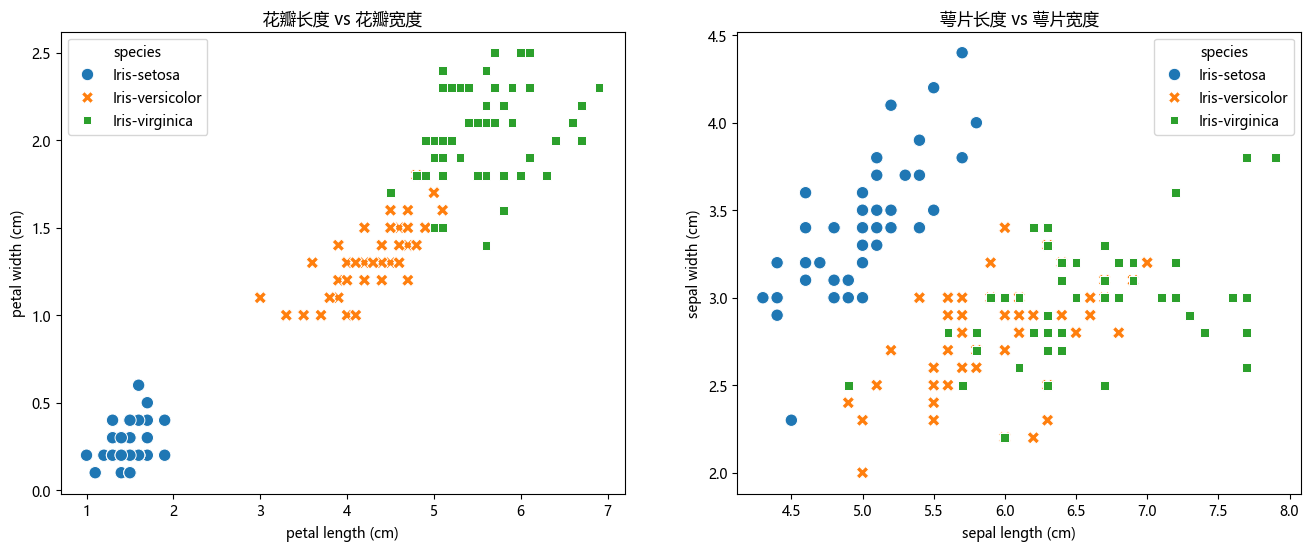

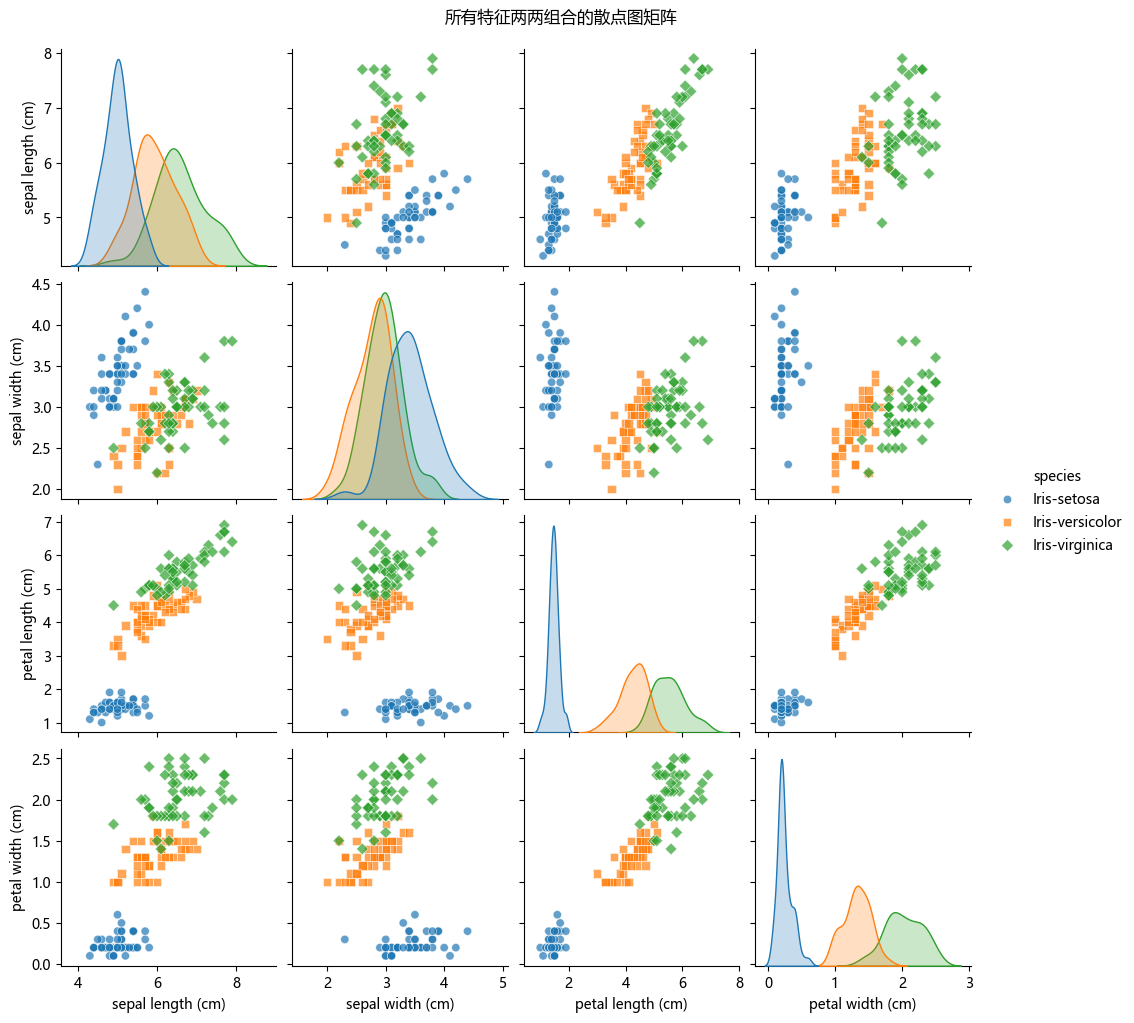

In [22]:
# 1. 基础散点图：花瓣长 vs 花瓣宽（最能体现可分性）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species', style='species', s=80, ax=ax1)
ax1.set_title('花瓣长度 vs 花瓣宽度')

# 2. 萼片长 vs 萼片宽
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='species', style='species', s=80, ax=ax2)
ax2.set_title('萼片长度 vs 萼片宽度')
plt.savefig('images/iris_scatter.png', dpi=150)
plt.show()

# 3. 散点图矩阵 (pairplot) —— 最重要的综合探索图形
pairplot_fig = sns.pairplot(df, hue='species', diag_kind='kde', markers=["o", "s", "D"], plot_kws={'alpha':0.7})
pairplot_fig.fig.suptitle('所有特征两两组合的散点图矩阵', y=1.02)
pairplot_fig.savefig('images/iris_pairplot.png', dpi=150)
plt.show()